ElasticNet Regression is a regularized linear regression method that combines both Lasso (L1 penalty) and Ridge (L2 penalty). 
It is particularly useful when the dataset has many correlated features(Multicolinearity) or when we want a balance between feature selection (like Lasso) and coefficient shrinkage (like Ridge).

Cost/Loss function = MSE + a ∑∣wi∣ + b ∑wi²
λ = a + b and l1_ratio = a/(a + b)
λ is the Constant that multiplies the penalty terms. Default value is 1.it is related to Ridge.
l1_ratio is the ElasticNet mixing parameter, with 0 <= l1_ratio <= 1.Default value is 0.5. Related to Lasso.

It handles multicollinearity better than Lasso.

It can select important features like Lasso while still keeping some stability from Ridge.

It is more flexible compared to using Lasso or Ridge alone.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import fetch_california_housing

In [13]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [14]:
x = df
y = data.target

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

In [16]:
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)
sc_y = StandardScaler()
y_train = sc_y.fit_transform(np.array(y_train).reshape(-1,1))

In [17]:
regressor = ElasticNet()

In [18]:
alphas = np.logspace(-4, 1, 100)
l1_ratios = np.linspace(0.1,0.9,9)
elcv = GridSearchCV(regressor,{'alpha':alphas,'l1_ratio':l1_ratios},scoring='neg_mean_squared_error',cv=5)
elcv.fit(x_train,y_train)

,estimator,ElasticNet()
,param_grid,"{'alpha': array([1.0000...00000000e+01]), 'l1_ratio': array([0.1, 0....7, 0.8, 0.9])}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(0....5024211399737)


In [20]:
print("Best Parameters:", elcv.best_params_)
print("Best Score:", elcv.best_score_)

Best Parameters: {'alpha': np.float64(0.002595024211399737), 'l1_ratio': np.float64(0.9)}
Best Score: -0.3928379530666391


In [21]:
y_pred_sc = elcv.predict(x_test)
y_pred = sc_y.inverse_transform(y_pred_sc.reshape(-1,1))

In [22]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [23]:
score = r2_score(y_test,y_pred) 
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.5972941773127225
MAE: 0.5275224434294276
MSE: 0.5285675439272298


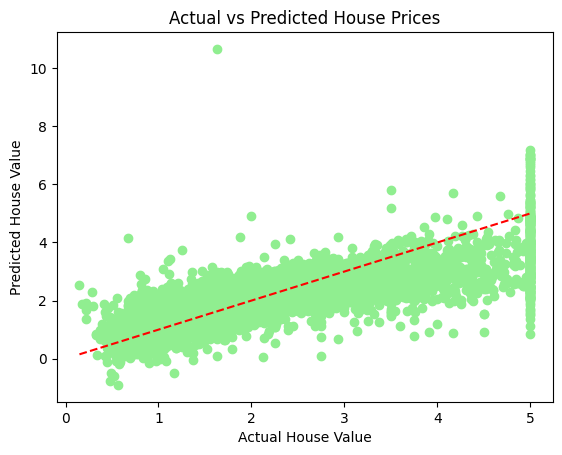

In [24]:
plt.scatter(y_test,y_pred,color="lightgreen")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color="red",linestyle="--")
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Prices')
plt.show()

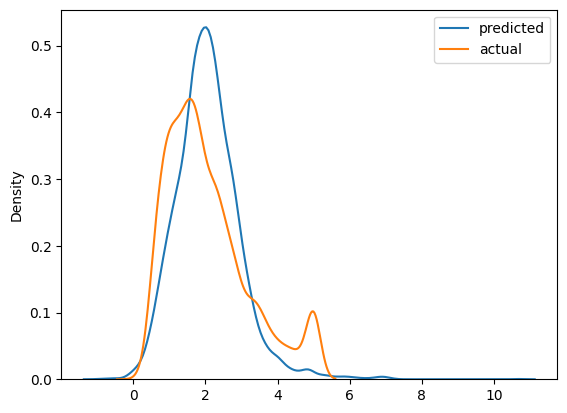

In [25]:
import seaborn as sns
sns.kdeplot(y_pred,label="predicted")
sns.kdeplot(y_test,label="actual")
plt.legend()

In [26]:
y_trains = sc_y.inverse_transform(y_train)
y_trains.max()

np.float64(5.00001)